# Hafta 1 · Ders 1 — Diziler Olarak Görüntüler

> **Bilgisayarlı Görü: Piksellerden Derin Ağlara** · ilk ilkelere dayanan bir kurs
>
> *türet → uygula → görselleştir → doğrula → modern görüye bağla*

Herhangi bir algoritmadan önce tek bir fikir: **bir dijital görüntü, yalnızca bir sayı ızgarasına örneklenmiş bir fonksiyondur.**
Gri tonlamalı bir görüntü 2B bir yoğunluklar dizisidir; renkli bir görüntü ise kırmızı, yeşil ve
mavi düzlemlerini üst üste yığan 3B bir dizidir. Bir görüntüyü bir dizi olarak gördüğünüzde, bu
kurstaki her işlem sıradan dizi aritmetiğine dönüşür — ve bütün mesele de budur.

Bu notebook bu temeli inşa eder: pikseller ve koordinatlar, kanallar ve renk, veri tipleri ve
aralıklar, dilimleme ve kırpma ve sonrasında gelen her şeyin altında yatan çözünürlük/örnekleme
ödünleşimi (trade-off).

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from utils.cv_utils import show, show_row, sample_gray, sample_rgb, to_gray, check

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1. Gri tonlamalı bir görüntü 2B bir dizidir

Her giriş bir **pikseldir** — tek bir yoğunluk değeri. Geleneksel olarak yoğunlukları
$[0, 1]$ aralığında float (0 = siyah, 1 = beyaz) veya $[0, 255]$ aralığında 8-bit tamsayı olarak
saklarız. Dizinin biçimi `(yükseklik, genişlik)`'tir ve — önemli olarak — **birinci indeks satırdır
(y), ikincisi sütundur (x)**, ki bu beklediğiniz $(x, y)$ sırasının tersidir.

shape (height, width): (128, 128)
dtype: float64  range: 0.0 to 1.0

top-left 4×4 block of pixel values:
 [[0.35  0.352 0.354 0.356]
 [0.35  0.352 0.354 0.356]
 [0.35  0.352 0.354 0.356]
 [0.35  0.352 0.354 0.356]]


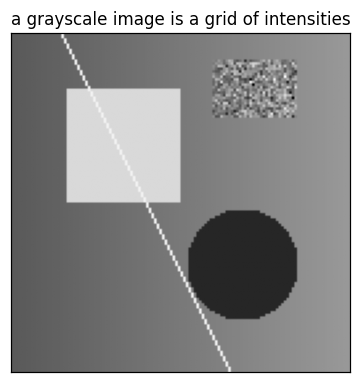

In [2]:
img = sample_gray(128)
print("biçim (yükseklik, genişlik):", img.shape)
print("dtype:", img.dtype, " aralık:", round(img.min(), 2), "-", round(img.max(), 2))
print("\nsol-üst 4×4 piksel değerleri bloğu:\n", img[:4, :4])

show(img, title="gri tonlamalı bir görüntü bir yoğunluk ızgarasıdır")
plt.show()

### Pikseller ve koordinatlar

Diziyi indekslemek bir piksel okur; ona atama yapmak ise bir piksel boyar. Dizi-eşittir-görüntü
denkliğini somutlaştırmak için tek bir pikseli ve küçük bir bloğu işaretleyelim. Unutmayın:
`img[row, col]` = `img[y, x]`.

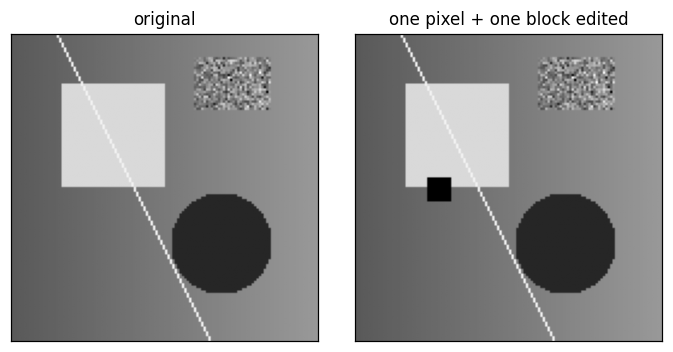

value we wrote at (row=20, col=100): 1.0


In [3]:
marked = img.copy()
marked[20, 100] = 1.0                 # satır 20, sütun 100'de tek bir parlak piksel
marked[60:70, 30:40] = 0.0            # siyah bir blok (satır 60–69, sütun 30–39)

show_row([img, marked], ["orijinal", "bir piksel + bir blok düzenlendi"])
plt.show()
print("(satır=20, sütun=100)'e yazdığımız değer:", marked[20, 100])

## 2. Renkli görüntüler: kanalları yığma

Renkli bir görüntü, boyutu 3 olan üçüncü bir eksen ekler: kırmızı, yeşil ve mavi **kanallar**.
Biçim `(yükseklik, genişlik, 3)` olur. Her kanal kendi başına gri tonlamalı bir görüntüdür; bunları
ayrı ayrı görüntülemek rengin nasıl oluştuğunu ortaya koyar.

RGB shape: (128, 128, 3)


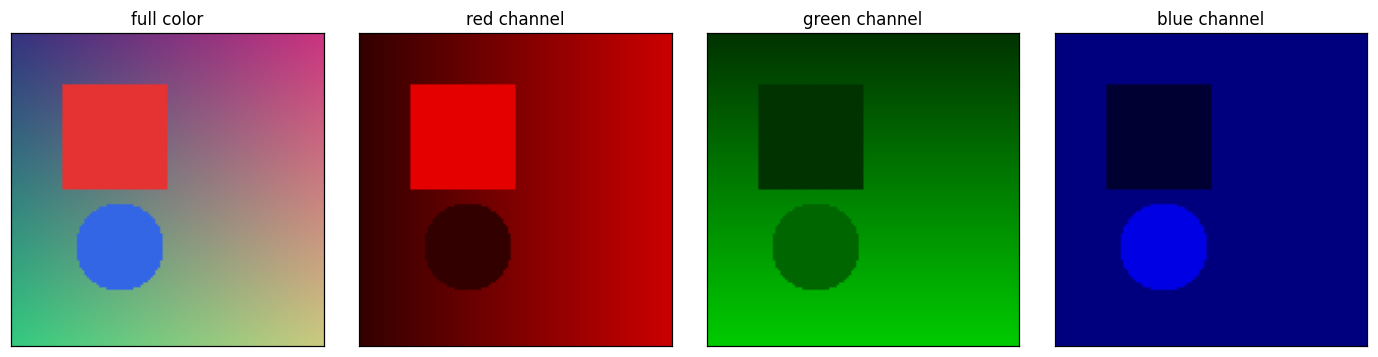

In [4]:
rgb = sample_rgb(128)
print("RGB biçim:", rgb.shape)

# diğerlerini sıfırlayarak her kanalı yalıt
def only(channel):
    out = np.zeros_like(rgb)
    out[..., channel] = rgb[..., channel]
    return out

show_row([rgb, only(0), only(1), only(2)],
         ["tam renk", "kırmızı kanal", "yeşil kanal", "mavi kanal"])
plt.show()

### Renkten gri tonlamaya: parlaklık (luminance)

Üç kanalı bire indirmek düz bir ortalama değildir — insan gözü yeşile maviden çok daha duyarlıdır.
Standart **parlaklık (luminance)** dönüşümü kanalları buna göre ağırlıklandırır:

$$ Y = 0.299\\,R + 0.587\\,G + 0.114\\,B $$

Bu, kanal ekseni boyunca bir iç çarpımdır — renk dönüşümünün doğrusal cebir olduğuna dair ilk ipucumuz.

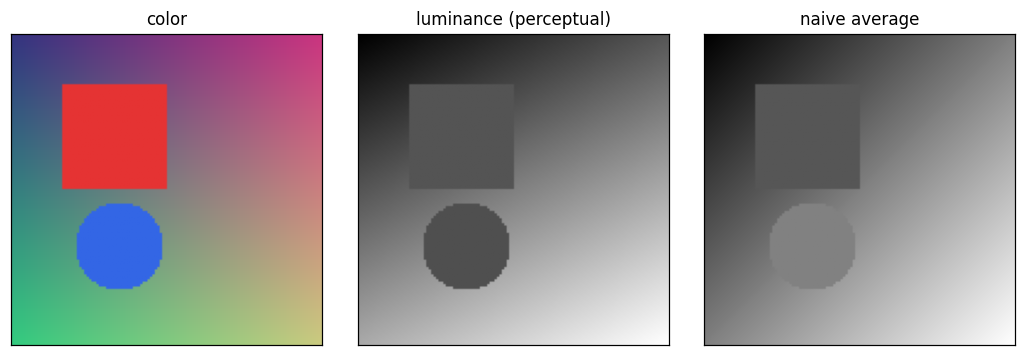

[PASS] luminance == weighted sum          max|Δ| = 1.11e-16


True

In [5]:
gray = to_gray(rgb)
naive = rgb.mean(axis=2)              # (yanlış) eşit-ağırlıklı ortalama

show_row([rgb, gray, naive],
         ["renk", "parlaklık (algısal)", "naif ortalama"])
plt.show()

# parlaklığımızı açık bir ağırlıklı toplama karşı doğrula
weights = np.array([0.299, 0.587, 0.114])
manual = rgb[..., 0]*weights[0] + rgb[..., 1]*weights[1] + rgb[..., 2]*weights[2]
check("parlaklık == ağırlıklı toplam", gray, manual)

## 3. Veri tipleri, aralıklar ve yaygın bir hata

İki gelenek bir arada bulunur: **$[0,1]$ aralığında float** ve **$[0,255]$ aralığında uint8**. Bunları
karıştırmak en yaygın görü hatalarından biridir — bir uint8 görüntüyü çarparsanız sessizce taşar ve
başa döner (overflow). Hangi gelenekte olduğunuzu her zaman bilin ve bilinçli olarak dönüştürün.

In [6]:
u8 = (img * 255).astype(np.uint8)         # float[0,1] → uint8[0,255] dönüşümü
print("uint8 aralık:", u8.min(), "-", u8.max())

# klasik taşma (overflow) hatası: uint8 aritmetiğinde 200 + 100, 255'i aşıp başa döner
a = np.array([200, 100, 50], dtype=np.uint8)
print("\nuint8 taşması:  200 + 100 =", (a[0] + np.uint8(100)), " (başa döndü, 300 değil!)")
print("güvenli yöntem:  önce float'a çevir →", float(a[0]) + 100.0)

back = u8.astype(float) / 255.0           # float[0,1]'e geri dönüştür
check("gidiş-dönüş float→uint8→float", back, img, atol=1/255 + 1e-9)

uint8 range: 0 to 255

uint8 overflow:  200 + 100 = 44  (wrapped, not 300!)
safe approach :  cast to float first → 300.0
[PASS] round-trip float→uint8→float       max|Δ| = 3.90e-03


/tmp/ipykernel_1033/1445374923.py:6: RuntimeWarning: overflow encountered in scalar add
  print("\nuint8 overflow:  200 + 100 =", (a[0] + np.uint8(100)), " (wrapped, not 300!)")


True

## 4. Çözünürlük ve örnekleme

Bir görüntü, sürekli bir sahnenin *örneklenmiş* bir versiyonudur. Daha az örnek (düşük çözünürlük)
daha kaba pikseller ve kaybolan ayrıntı demektir — herhangi bir sinyaldekiyle aynı örnekleme öyküsü.
Her $k$'inci pikseli alarak alt örnekleme yapmak bu ödünleşimi görünür kılar ve takma adlanmayı
(aliasing) önlemek için neden *alt örneklemeden önce bulanıklaştırmamız* gerektiğini (Hafta 2)
önceden gösterir.

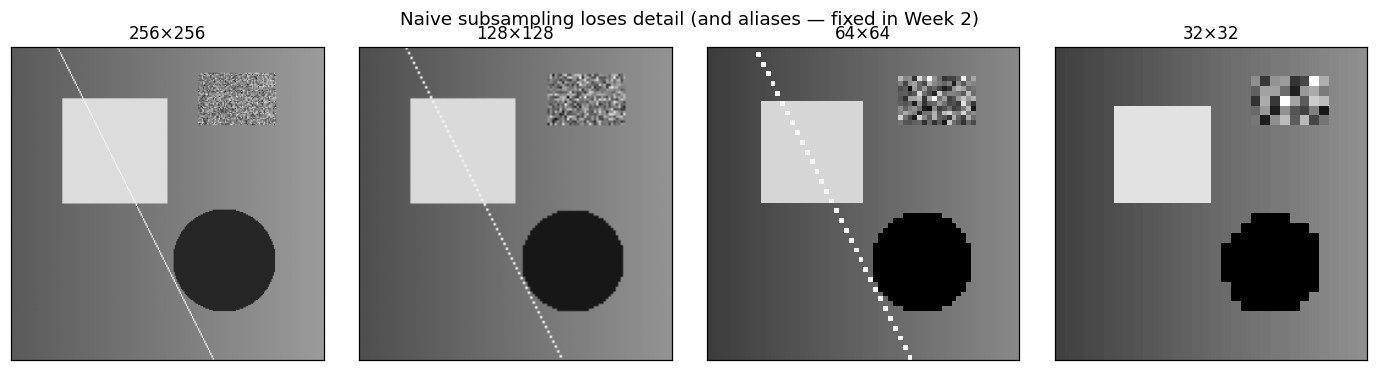

In [7]:
fine = sample_gray(256)
levels = [fine, fine[::2, ::2], fine[::4, ::4], fine[::8, ::8]]
titles = [f"{im.shape[0]}×{im.shape[1]}" for im in levels]
show_row(levels, titles)
plt.suptitle("Naif alt örnekleme ayrıntıyı kaybeder (ve takma ad oluşturur — Hafta 2'de düzeltiliyor)", y=1.04)
plt.show()

## 5. Bunun modern görüde nerede karşımıza çıktığı

- **Tensörler, diziler-olarak-görüntülerin genelleştirilmiş halidir.** Bir derin öğrenme yığını
  (batch) `(batch, channels, height, width)` biçimindedir — tam olarak bu notebook'un fikri, iki
  ekstra eksenle.
- **Normalizasyon** (bir ortalamayı çıkarma, $[0,1]$ aralığına veya birim varyansa ölçekleme),
  §3'teki float-aralığı disiplinidir ve aslında her görü hattının (pipeline) ilk katmanıdır.
- RGB'nin ötesindeki **renk uzayları** (HSV, LAB, YCbCr), kanal ekseni üzerinde öğrenilmiş veya elle
  tasarlanmış doğrusal/doğrusal olmayan eşlemelerdir — parlaklık iç çarpımını genelleştirir.

Temel ön işleme adımı olan normalizasyonu önceden görelim.

before:  mean = 0.49  std = 0.115
after :  mean = -0.0  std = 1.0


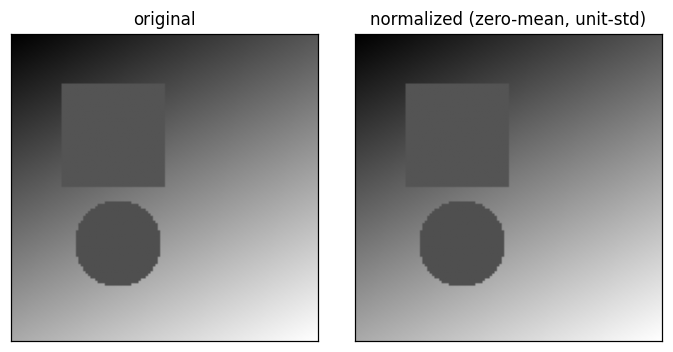

In [8]:
def normalize(im):
    return (im - im.mean()) / (im.std() + 1e-8)

norm = normalize(gray)
print("önce:  ortalama =", round(gray.mean(), 3), " std =", round(gray.std(), 3))
print("sonra: ortalama =", round(norm.mean(), 3), " std =", round(norm.std(), 3))
show_row([gray, norm], ["orijinal", "normalize edilmiş (sıfır-ortalama, birim-std)"])
plt.show()

## Alıştırmalar

1. **Çevir ve döndür.** Yalnızca dizi işlemleri kullanarak (dilimleme, `.T`), bir görüntüyü yatay ve dikey olarak çevir ve 90° döndür. Kütüphane çağrısı yok.
2. **Kanal değişimi.** Bir RGB görüntünün kırmızı ve mavi kanallarını değiştir ve etkisini gözlemle. Bu hangi tanıdık bozulmaya (artifact) benziyor?
3. **İlgi alanına kırp (ROI).** Yalnızca dilimleme kullanarak, `sample_gray` içindeki koyu diski merkez alan kare bir ilgi bölgesi (region of interest) çıkar.

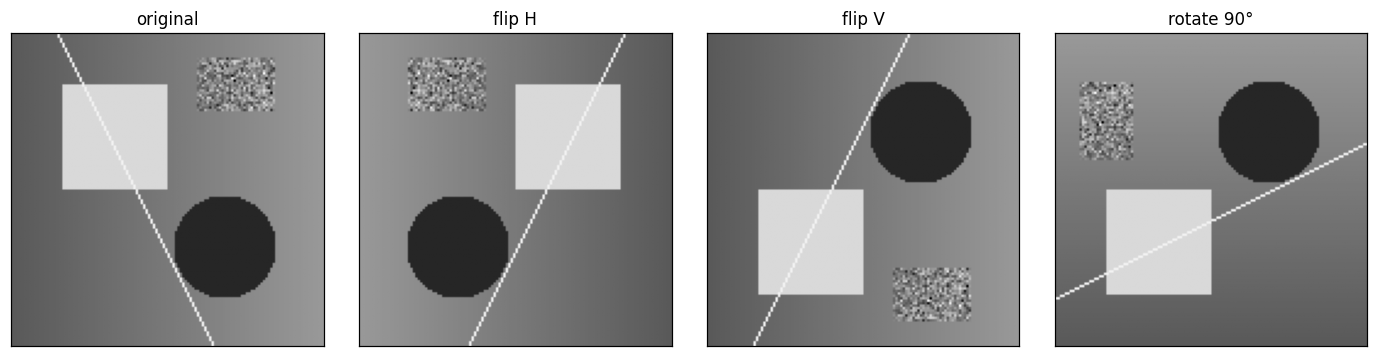

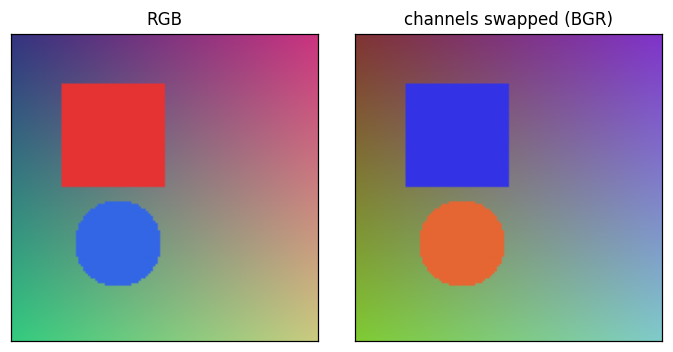

In [9]:
# === Çözümler (önce kendiniz deneyin!) ===

# 1.
flip_h = img[:, ::-1]
flip_v = img[::-1, :]
rot90  = img.T[::-1, :]
show_row([img, flip_h, flip_v, rot90], ["orijinal", "yatay çevir", "dikey çevir", "90° döndür"])
plt.show()

# 2. R↔B değişimi sıcak tonları soğuğa çevirir — klasik "BGR vs RGB" karışıklığı (örn. OpenCV)
swapped = rgb[..., ::-1]
show_row([rgb, swapped], ["RGB", "kanallar değiştirildi (BGR)"])
plt.show()

## Özet ve sırada ne var

Bir görüntü bir dizidir: gri tonlama için 2B, renk için 3B. İndeksleme pikselleri okur ve yazar,
kanallar yığılarak rengi oluşturur, veri tipi gelenekleri önemlidir ve çözünürlük örneklemedir.
Sonraki her operatör bu diziler üzerinde aritmetiktir.

**Sırada — `02_point_operations_histograms.ipynb`:** görüntüleri her seferinde bir piksel
dönüştürürüz — parlaklık, kontrast, gama, eşikleme — ve istatistiklerini tüm görüntü işlemenin en
faydalı tanı aracı olan **histogram** üzerinden okuruz.

---
*Bilgisayarlı Görü · Hafta 1 · Ders 1*